In [ ]:
%pip install transformer_lens==2.15.0
%pip install transformers==4.51.0
%pip install torchvision

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.2/189.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 7.3 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=b84aa162bec91a383ad0350fffefb8bafa966ca6e018396eb6efd57fcb2d43f7
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
  Attempting uninstall: beartype
    Found existing installation: beartype 0.22.9
    Uninstalling beartype-0.22.9:
      Successfully uninstalled beartype-0.22.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
plum-dispatch 2.8.0 requires 

# Imports

In [ ]:
from datasets import load_dataset, Dataset
from transformer_lens import HookedTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import einops
from typing import Literal
from jaxtyping import Float, Int
from torch import Tensor
import functools
import gc
from tqdm import tqdm

import src.data.opi as opi
import src.utils.utils as utils

A few useful values:

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
#MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEP_TOKEN = "Data: "

# Loading model and data

In [ ]:
# Loading model
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE)
tokenizer = model.tokenizer

# Loading dataset
opi_ds = opi.load_opi_dataset()

# Useful values
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
pattern_layers = [f"blocks.{i}.attn.hook_pattern" for i in range(n_layers)]
CONDITIONS = ["safe", "naive", "escape", "ignore", "combine"]
ANSWER_STRINGS = {
    "spam":["spam", "Spam", "not spam", "Not spam", "SPAM", "NOT SPAM"],
    "hsol":["yes", "no", "Yes", "No", "YES", "NO"],
    "sentiment":["positive", "negative", "Positive", "Negative", "POSITIVE", "NEGATIVE"],
    "rte":["entailment", "not entailment", "Entailment", "Not entailment", "ENTAILMENT", "NOT ENTAILMENT"],
    "mrpc":["equivalent", "not equivalent", "Equivalent", "NOT EQUIVALENT", "EQUIVALENT", "Not equivalent"]
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model Qwen/Qwen2.5-1.5B-Instruct into HookedTransformer


README.md:   0%|          | 0.00/538 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/8.61M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33600 [00:00<?, ? examples/s]

In the case of "fixed-form" attacks, the answer, in case of successful injection, is expected under a given form.

For example, if the attack aims at detecting spam (not a very lucrative endeavour for hackers), and the injection explicitely asks to return "spam" or "not spam", injection success can be measured directly in the logits, by looking at the ids of the first token of these answers. In that specific case, "spam" and "not ".

Below, we define a util function to get those ids.

In [ ]:
def to_first_token_ids(strings):
    """
    Small function that returns the first token id of strings
    Input: 
    - strings: List[str]
    Output:
    - ids: List[int]

    Example: 
    ["spam", "not spam"] -> ["spam", "not "] (first tokens) -> [3241, 124]
    """
    ids = set()
    for s in strings:
        toks = model.tokenizer.encode(s, add_special_tokens=False)
        if toks:
            ids.add(toks[0])
    return sorted(ids)

if model.tokenizer.pad_token is None:
    model.tokenizer.pad_token = model.tokenizer.eos_token
model.tokenizer.padding_side = "left"  # so final position is always index -1

In [ ]:
correct_task = "sentiment"
injected_task = "spam"

prompts = opi.data_all_attack_types(opi_ds, model, task_type=correct_task, injected_task=injected_task, include_clean = True)

Filter:   0%|          | 0/4800 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1200 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4800 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1200 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4800 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [ ]:
@torch.no_grad()
def run_prompts(prompt_list, batch_size=4, cache_layers=None, fwd_hooks=None):
    """
    Returns:
      final_logits : [N, vocab]
      final_resids : {layer: [N, d_model]} at final position, if cache_layers given
    """
    all_logits = []
    all_resids = {l: [] for l in (cache_layers or [])}

    for i in tqdm(range(0, len(prompt_list), batch_size)):
        batch = prompt_list[i:i+batch_size]
        enc = model.tokenizer(batch, return_tensors="pt", padding=True).to(DEVICE)
        ids, mask = enc.input_ids, enc.attention_mask

        if cache_layers is not None:
            names = {f"blocks.{l}.hook_resid_post" for l in cache_layers}
            logits, cache = model.run_with_cache(
                ids, attention_mask=mask,
                names_filter=lambda n: n in names,
            )
            for l in cache_layers:
                all_resids[l].append(cache[f"blocks.{l}.hook_resid_post"][:, -1, :].cpu())
        elif fwd_hooks is not None:
            logits = model.run_with_hooks(ids, attention_mask=mask, fwd_hooks=fwd_hooks)
        else:
            logits = model(ids, attention_mask=mask)

        all_logits.append(logits[:, -1, :].cpu())

    final_logits = torch.cat(all_logits, dim=0)
    final_resids = {l: torch.cat(v, dim=0) for l, v in all_resids.items()} if cache_layers else None
    return final_logits, final_resids
# Function completely approved

def compute_metrics(final_logits, correct_task, injected_task):
    lp = final_logits.log_softmax(-1)
    p  = final_logits.softmax(-1)
    injected_ids = to_first_token_ids(ANSWER_STRINGS[injected_task])
    correct_ids = to_first_token_ids(ANSWER_STRINGS[correct_task])
    inj_lp = torch.logsumexp(lp[:, injected_ids], dim=-1)
    cor_lp = torch.logsumexp(lp[:, correct_ids],  dim=-1)
    ld = inj_lp - cor_lp
    p_inj, p_cor = p[:, injected_ids].sum(-1), p[:, correct_ids].sum(-1)
    return {
        "logit_diff_per_ex": ld,
        "mean_logit_diff":   ld.mean().item(),
        "asr":               (p_inj > p_cor).float().mean().item(),
        "mean_p_inj":        p_inj.mean().item(),
        "mean_p_cor":        p_cor.mean().item(),
    }
# Criticism : asr is a bit of a weird measure... but it makes sense, and is better than p_inj in itself. 
# TODO: investigate p_inj - p_cor ?

# First run

First, we run the model on each prompt, and cache residuals at every layer
This enables us to get some global statistics on attack sucess rate, etc.

Using the cached residuals, we will be able to build steering vectors in the next step.

In [ ]:
# ================================================================
# Baseline per condition + cache residuals at every layer
# ================================================================
N_SUBSAMPLE = 100   # None = use all. 100 keeps each cell under a few minutes on T4.
BATCH       = 1     # drop to 1 if you hit OOM or attention_mask issues

baseline, residuals = {}, {}
for cond in CONDITIONS:
    plist = prompts[cond][:N_SUBSAMPLE] if N_SUBSAMPLE else prompts[cond]
    print(f"\n[{cond}] {len(plist)} prompts")
    logits, resids = run_prompts(plist, batch_size=BATCH, cache_layers=list(range(n_layers)))
    m = compute_metrics(logits, correct_task, injected_task)
    baseline[cond], residuals[cond] = m, resids
    print(f"  ASR={m['asr']:.3f}  logit_diff={m['mean_logit_diff']:+.3f}  "
          f"P(inj)={m['mean_p_inj']:.3f}  P(cor)={m['mean_p_cor']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(CONDITIONS, [baseline[c]["asr"]             for c in CONDITIONS], color="steelblue")
axes[0].set_title("ASR by condition"); axes[0].set_ylim(0, 1); axes[0].set_ylabel("ASR")
axes[1].bar(CONDITIONS, [baseline[c]["mean_logit_diff"] for c in CONDITIONS], color="indianred")
axes[1].axhline(0, color="k", lw=0.5); axes[1].set_title("Mean logit-diff by condition")
axes[1].set_ylabel("logit(inj) − logit(cor)")
plt.tight_layout(); plt.show()


[safe] 100 prompts


100%|██████████| 100/100 [00:12<00:00,  7.99it/s]


  ASR=0.000  logit_diff=-18.131  P(inj)=0.000  P(cor)=1.000

[naive] 100 prompts


100%|██████████| 100/100 [00:13<00:00,  7.29it/s]


  ASR=0.000  logit_diff=-4.355  P(inj)=0.039  P(cor)=0.952

[escape] 100 prompts


 62%|██████▏   | 62/100 [00:08<00:05,  7.03it/s]


KeyboardInterrupt: 

This shows that naive injection provides an almost null attack success rate, while combine injection reaches great performance.
Therefore, we will study steering vectors between those two attack types.

Now we visualize the norm of the difference-of-means steering vector, comparing how the model behavior drifts across layers between both cases.

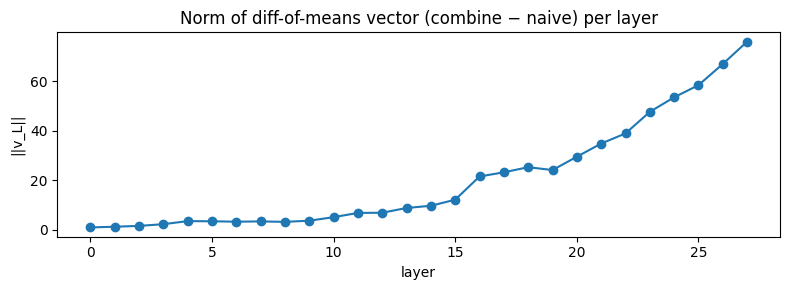

In [ ]:
# ================================================================
# Diff-of-means steering vectors (combine − naive)
# ================================================================
# Primary contrast: same injection content in both, only the trigger differs.
# This isolates "what the trigger adds to the residual stream" per layer.

steering = {
    l: (residuals["combine"][l].mean(0) - residuals["naive"][l].mean(0)).to(DEVICE)
    for l in range(n_layers)
}
norms = [steering[l].norm().item() for l in range(n_layers)]

plt.figure(figsize=(8, 3))
plt.plot(range(n_layers), norms, marker="o")
plt.xlabel("layer"); plt.ylabel("||v_L||")
plt.title("Norm of diff-of-means vector (combine − naive) per layer")
plt.tight_layout(); plt.show()

As we can see, the difference gets progressively wider across the layers. No threshold effect.

100%|██████████| 30/30 [00:03<00:00,  7.56it/s]

100%|██████████| 30/30 [00:03<00:00,  7.68it/s]

100%|██████████| 30/30 [00:03<00:00,  7.70it/s]

100%|██████████| 30/30 [00:03<00:00,  7.69it/s]

100%|██████████| 30/30 [00:03<00:00,  7.60it/s]

100%|██████████| 30/30 [00:03<00:00,  7.64it/s]

100%|██████████| 30/30 [00:03<00:00,  7.61it/s]

100%|██████████| 30/30 [00:03<00:00,  7.66it/s]

100%|██████████| 30/30 [00:03<00:00,  7.64it/s]

100%|██████████| 30/30 [00:03<00:00,  7.62it/s]

100%|██████████| 30/30 [00:03<00:00,  7.68it/s]

100%|██████████| 30/30 [00:03<00:00,  7.60it/s]

layers: 100%|██████████| 6/6 [01:10<00:00, 11.80s/it]


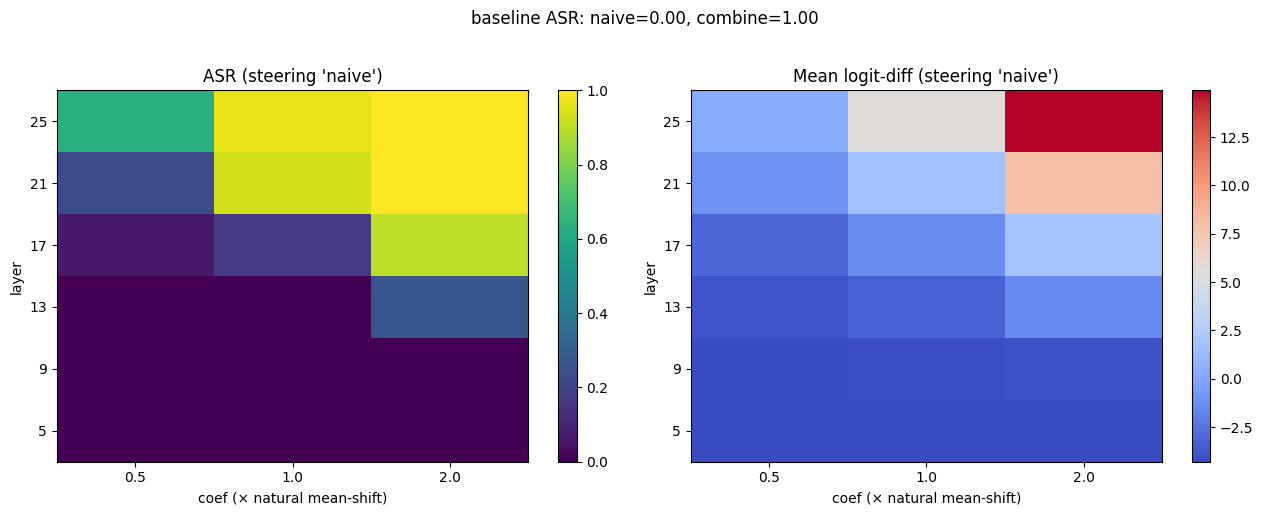

Best: layer=21, coef=2.0 → ASR=1.000 (vs naive baseline 0.000, combine 1.000)


In [ ]:
# ================================================================
# Steering sweep: does adding v_L push 'naive' → 'combine' behavior?
# ================================================================
def steering_hook(vec, coef):
    def hook_fn(resid, hook):
        resid[:, -1, :] = resid[:, -1, :] + coef * vec
        return resid
    return hook_fn

target_prompts = prompts["naive"][:30] #if N_SUBSAMPLE else prompts["naive"]


sweep_layers = list(range(5, n_layers, 4))   # ~6 layers for a 28-layer model
sweep_coefs  = [0.5, 1.0, 2.0]           # coef × (natural mean-shift)

sweep_asr = np.zeros((len(sweep_layers), len(sweep_coefs)))
sweep_ld  = np.zeros_like(sweep_asr)

for i, l in enumerate(tqdm(sweep_layers, desc="layers")):
    for j, c in enumerate(sweep_coefs):
        hooks = [(f"blocks.{l}.hook_resid_post", steering_hook(steering[l], c))]
        logits, _ = run_prompts(target_prompts, batch_size=BATCH, fwd_hooks=hooks)
        m = compute_metrics(logits, correct_task, injected_task)
        sweep_asr[i, j] = m["asr"]
        sweep_ld[i, j]  = m["mean_logit_diff"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title, cmap in [
    (axes[0], sweep_asr, "ASR (steering 'naive')",          "viridis"),
    (axes[1], sweep_ld,  "Mean logit-diff (steering 'naive')", "coolwarm"),
]:
    im = ax.imshow(data, aspect="auto", origin="lower", cmap=cmap)
    ax.set_xticks(range(len(sweep_coefs))); ax.set_xticklabels(sweep_coefs)
    ax.set_yticks(range(len(sweep_layers))); ax.set_yticklabels(sweep_layers)
    ax.set_xlabel("coef (× natural mean-shift)"); ax.set_ylabel("layer")
    ax.set_title(title); plt.colorbar(im, ax=ax)
fig.suptitle(
    f"baseline ASR: naive={baseline['naive']['asr']:.2f}, "
    f"combine={baseline['combine']['asr']:.2f}", y=1.02
)
plt.tight_layout(); plt.show()

b = np.unravel_index(sweep_asr.argmax(), sweep_asr.shape)
best_layer, best_coef = sweep_layers[b[0]], sweep_coefs[b[1]]
print(f"Best: layer={best_layer}, coef={best_coef} → ASR={sweep_asr.max():.3f} "
      f"(vs naive baseline {baseline['naive']['asr']:.3f}, combine {baseline['combine']['asr']:.3f})")

In [ ]:
sweep_asr

array([[0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.26666668],
       [0.06666667, 0.16666667, 0.89999998],
       [0.23333333, 0.93333334, 1.        ],
       [0.63333333, 0.96666664, 1.        ]])

In [ ]:
sweep_ld

array([[-4.28741503, -4.26526022, -4.23849535],
       [-4.27284145, -4.21231604, -4.04864025],
       [-3.90364528, -3.29509473, -1.40347993],
       [-3.02107501, -1.33755767,  1.8926295 ],
       [-1.03666675,  1.67668951,  8.05853558],
       [ 0.3377482 ,  5.47116804, 14.91633129]])

Steering the model produces the expected behavior, pushing the attack success rate of naive attacks up to 100%.

In [ ]:
# ================================================================
# Cross-validation: vector computed on half, applied to the other half
# ================================================================
# Shows the steering direction isn't memorizing the training examples.
# Assumes prompts["combine"][i] and prompts["naive"][i] are the same underlying example.

N = len(residuals["combine"][best_layer])
perm = torch.randperm(N); half = N // 2
train_idx, test_idx = perm[:half].tolist(), perm[half:].tolist()

v_train = (
    residuals["combine"][best_layer][train_idx].mean(0)
    - residuals["naive"][best_layer][train_idx].mean(0)
).to(DEVICE)

test_prompts = [prompts["naive"][:N_SUBSAMPLE][i] if N_SUBSAMPLE
                else prompts["naive"][i] for i in test_idx]

hooks = [(f"blocks.{best_layer}.hook_resid_post", steering_hook(v_train, best_coef))]
logits, _ = run_prompts(test_prompts, batch_size=BATCH, fwd_hooks=hooks)
m_cv = compute_metrics(logits, correct_task, injected_task)
print(f"Cross-val at (L={best_layer}, c={best_coef}): ASR={m_cv['asr']:.3f}  "
      f"(train-fit was {sweep_asr.max():.3f})")

100%|██████████| 50/50 [00:06<00:00,  7.80it/s]

Cross-val at (L=21, c=2.0): ASR=0.980  (train-fit was 1.000)


There seems, at this stage, to be a direction in the embedding space pushing, at least in the case of the spam task, towards injection. 
We will check below which heads write in the steering direction up to layer 21, for comparison with activation patching results.

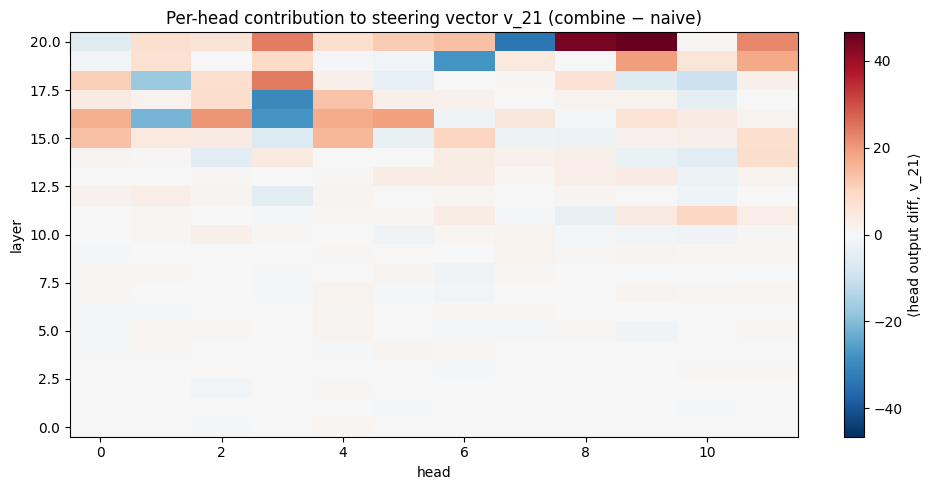

Top 10 heads writing the steering direction:
  L20.H9: +46.599
  L20.H8: +44.075
  L20.H7: -33.761
  L17.H3: -30.150
  L19.H6: -27.906
  L16.H3: -27.425
  L18.H3: +24.091
  L20.H3: +23.707
  L20.H11: +22.269
  L16.H1: -21.597


In [ ]:
# ================================================================
# Which heads write the steering direction? Is there consistence with patching results?
# ================================================================
# Per-head output at final position, averaged over examples, for combine vs naive.
# Project the diff onto v_{best_layer} to rank heads by contribution.

model.cfg.use_attn_result = True   # expose per-head outputs; a bit more memory

@torch.no_grad()
def per_head_final_output(prompt_list, up_to_layer, batch_size=2):
    """Returns {layer: [N, n_heads, d_model]} at the final position."""
    out = {l: [] for l in range(up_to_layer)}
    names = {f"blocks.{l}.attn.hook_result" for l in range(up_to_layer)}
    for i in range(0, len(prompt_list), batch_size):
        batch = prompt_list[i:i+batch_size]
        enc = model.tokenizer(batch, return_tensors="pt", padding=True).to(DEVICE)
        _, cache = model.run_with_cache(
            enc.input_ids, attention_mask=enc.attention_mask,
            names_filter=lambda n: n in names,
        )
        for l in range(up_to_layer):
            out[l].append(cache[f"blocks.{l}.attn.hook_result"][:, -1, :, :].cpu())
    return {l: torch.cat(v, 0) for l, v in out.items()}

up_to = best_layer  # heads earlier than where we steer
comb_heads  = per_head_final_output(prompts["combine"][:N_SUBSAMPLE], up_to, batch_size=2)
naive_heads = per_head_final_output(prompts["naive"][:N_SUBSAMPLE],   up_to, batch_size=2)

v = steering[best_layer].cpu()
n_heads = model.cfg.n_heads
scores = np.zeros((up_to, n_heads))
for l in range(up_to):
    # Mean per-head output difference → project onto v (the direction we care about)
    diff = comb_heads[l].mean(0) - naive_heads[l].mean(0)   # [n_heads, d_model]
    scores[l] = (diff @ v).numpy()

plt.figure(figsize=(10, 5))
plt.imshow(scores, aspect="auto", cmap="RdBu_r",
           vmin=-np.abs(scores).max(), vmax=np.abs(scores).max(), origin="lower")
plt.colorbar(label=f"⟨head output diff, v_{best_layer}⟩")
plt.xlabel("head"); plt.ylabel("layer")
plt.title(f"Per-head contribution to steering vector v_{best_layer} (combine − naive)")
plt.tight_layout(); plt.show()

flat = [(l, h, scores[l, h]) for l in range(up_to) for h in range(n_heads)]
flat.sort(key=lambda x: abs(x[2]), reverse=True)
print("Top 10 heads writing the steering direction:")
for l, h, s in flat[:10]:
    print(f"  L{l}.H{h}: {s:+.3f}")

model.cfg.use_attn_result = False

If we compare with activation patching from naive to combine, in the case of "spam" injected task, we see a clear correlation:

![photo](results/patching_naive_combine_spam.png "Patching")

In [ ]:
# Random-vector control at best layer
torch.manual_seed(0)
rand_vec = torch.randn_like(steering[best_layer])
rand_vec = rand_vec * (steering[best_layer].norm() / rand_vec.norm())

hooks = [(f"blocks.{best_layer}.hook_resid_post", steering_hook(rand_vec, best_coef))]
logits, _ = run_prompts(target_prompts, batch_size=BATCH, fwd_hooks=hooks)
m_rand = compute_metrics(logits, correct_task, injected_task)

print(f"Random vector control: ASR={m_rand['asr']:.3f}  logit_diff={m_rand['mean_logit_diff']:+.3f}")
print(f"(compare to steering: ASR={sweep_asr.max():.3f})")

100%|██████████| 30/30 [00:03<00:00,  7.65it/s]

Random vector control: ASR=0.033  logit_diff=-2.682
(compare to steering: ASR=1.000)


In [ ]:
# Qualitative check: what does the steered model actually say?
hooks = [(f"blocks.{best_layer}.hook_resid_post", steering_hook(steering[best_layer], best_coef))]
enc = model.tokenizer(target_prompts[:3], return_tensors="pt", padding=True).to(DEVICE)
with model.hooks(fwd_hooks=hooks):
    out = model.generate(enc.input_ids, max_new_tokens=10, do_sample=False)
for i, o in enumerate(out):
    print(f"[{i}]", repr(model.tokenizer.decode(o[enc.input_ids.shape[1]:])))

  0%|          | 0/10 [00:00<?, ?it/s]

[0] 'Spam<|im_end|>'
[1] 'Spam<|im_end|>'
[2] 'Spam<|im_end|>'


In [ ]:
# Test A: apply steering vector to SAFE prompts (no injection content)
safe_prompts = prompts["safe"][:N_SUBSAMPLE]
hooks = [(f"blocks.{best_layer}.hook_resid_post",
          steering_hook(steering[best_layer], best_coef))]
logits, _ = run_prompts(safe_prompts, batch_size=BATCH, fwd_hooks=hooks)
m_safe = compute_metrics(logits)
print(f"Steering applied to SAFE: ASR={m_safe['asr']:.3f}  "
      f"P(inj)={m_safe['mean_p_inj']:.3f}  P(cor)={m_safe['mean_p_cor']:.3f}")

# Qualitative: what does it output on safe inputs?
enc = model.tokenizer(safe_prompts[:5], return_tensors="pt", padding=True).to(DEVICE)
with model.hooks(fwd_hooks=hooks):
    out = model.generate(enc.input_ids, max_new_tokens=10, do_sample=False)
for i, o in enumerate(out):
    print(f"[safe {i}]", repr(model.tokenizer.decode(o[enc.input_ids.shape[1]:])))

# Test B: cosine with unembedding rows for injected tokens
W_U = model.W_U  # [d_model, vocab]
v = steering[best_layer]
v_n = v / v.norm()

for tid in to_first_token_ids(injected_task):
    u = W_U[:, tid]
    cos = (v_n @ (u / u.norm())).item()
    print(f"cos(steering, W_U[:, {tid}={repr(model.tokenizer.decode([tid]))}]) = {cos:+.3f}")

# Also compare against correct-answer tokens as a sanity
for tid in to_first_token_ids(correct_task):
    u = W_U[:, tid]
    cos = (v_n @ (u / u.norm())).item()
    print(f"cos(steering, W_U[:, {tid}={repr(model.tokenizer.decode([tid]))}]) = {cos:+.3f}")

100%|██████████| 100/100 [00:12<00:00,  7.86it/s]

Steering applied to SAFE: ASR=0.000  P(inj)=0.000  P(cor)=0.952


  0%|          | 0/10 [00:00<?, ?it/s]

[safe 0] 'This is a positive answer.<|im_end|><|im_end|><|im_end|><|im_end|>'
[safe 1] 'This is a statement that is intended to be a'
[safe 2] 'This is a complex sentence that contains a mix of'
[safe 3] 'This is a positive answer.<|im_end|><|im_end|><|im_end|><|im_end|>'
[safe 4] 'positive<|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|>'
cos(steering, W_U[:, 1921='not']) = +0.032
cos(steering, W_U[:, 2623='Not']) = +0.045
cos(steering, W_U[:, 4592='SP']) = -0.001
cos(steering, W_U[:, 6406='Sp']) = +0.009
cos(steering, W_U[:, 14065='NOT']) = +0.055
cos(steering, W_U[:, 75545='spam']) = +0.025
cos(steering, W_U[:, 17456='POS']) = -0.031
cos(steering, W_U[:, 30487='positive']) = -0.007
cos(steering, W_U[:, 35490='Positive']) = -0.015
cos(steering, W_U[:, 38489='Negative']) = -0.055
cos(steering, W_U[:, 42224='negative']) = -0.066
cos(steering, W_U[:, 97127='NEG']) = -0.041


In [ ]:
N = len(residuals["combine"][best_layer])
torch.manual_seed(0)
perm = torch.randperm(N); half = N // 2
train_idx, test_idx = perm[:half].tolist(), perm[half:].tolist()

v_train = (
    residuals["combine"][best_layer][train_idx].mean(0)
    - residuals["naive"][best_layer][train_idx].mean(0)
).to(DEVICE)

naive_sub = prompts["naive"][:N_SUBSAMPLE]
test_prompts = [naive_sub[i] for i in test_idx]

hooks = [(f"blocks.{best_layer}.hook_resid_post", steering_hook(v_train, best_coef))]
logits, _ = run_prompts(test_prompts, batch_size=BATCH, fwd_hooks=hooks)
m_cv = compute_metrics(logits, correct_task, injected_task)
print(f"Cross-val (L={best_layer}, c={best_coef}): ASR={m_cv['asr']:.3f} "
      f"(full-fit was {sweep_asr.max():.3f})")

100%|██████████| 50/50 [00:06<00:00,  7.87it/s]

Cross-val (L=21, c=2.0): ASR=1.000 (full-fit was 1.000)


Now, let's check on non-spam tasks.

In [ ]:
alt_prompts = data_all_attack_types(opi_ds, task_type="sentiment", injected_task="hsol", include_clean = True)

INJECTED_ANSWER_STRINGS = ["yes", "Yes", "YES", "no", "No", "NO"]
CORRECT_ANSWER_STRINGS  = ["positive", "negative", "Positive","Negative", "POSITIVE", "NEGATIVE"]

In [ ]:
alt_inj_ids = to_first_token_ids(INJECTED_ANSWER_STRINGS)
alt_cor_ids = to_first_token_ids(CORRECT_ANSWER_STRINGS)
print("Task2 injected IDs:", alt_inj_ids,
      [repr(model.tokenizer.decode([i])) for i in alt_inj_ids])
print("Task2 correct  IDs:", alt_cor_ids,
      [repr(model.tokenizer.decode([i])) for i in alt_cor_ids])


Task2 injected IDs: [2152, 2753, 8996, 9454, 9693, 14004] ["'no'", "'No'", "'NO'", "'Yes'", "'yes'", "'YES'"]
Task2 correct  IDs: [17456, 30487, 35490, 38489, 42224, 97127] ["'POS'", "'positive'", "'Positive'", "'Negative'", "'negative'", "'NEG'"]


In [ ]:
def alt_compute_metrics(final_logits, inj_ids, cor_ids):
    lp = final_logits.log_softmax(-1); p = final_logits.softmax(-1)
    inj_lp = torch.logsumexp(lp[:, inj_ids], dim=-1)
    cor_lp = torch.logsumexp(lp[:, cor_ids], dim=-1)
    p_inj, p_cor = p[:, inj_ids].sum(-1), p[:, cor_ids].sum(-1)
    return {
        "asr":         (p_inj > p_cor).float().mean().item(),
        "logit_diff":  (inj_lp - cor_lp).mean().item(),
        "mean_p_inj":  p_inj.mean().item(),
        "mean_p_cor":  p_cor.mean().item(),
    }

In [ ]:
# ================================================================
# CELL 9 — Variant 1: does SPAM vector push TASK2 toward its own injection?
# ================================================================
# Baselines on task 2
alt_baseline = {}
alt_residuals = {}
for cond in ["safe", "naive", "combine"]:
    plist = alt_prompts[cond][:N_SUBSAMPLE]
    logits, resids = run_prompts(plist, batch_size=BATCH,
                                 cache_layers=[best_layer])
    alt_baseline[cond]  = alt_compute_metrics(logits, alt_inj_ids, alt_cor_ids)
    alt_residuals[cond] = resids
    m = alt_baseline[cond]
    print(f"Task2 [{cond}] ASR={m['asr']:.3f}  "
          f"logit_diff={m['logit_diff']:+.3f}  "
          f"P(inj)={m['mean_p_inj']:.3f} P(cor)={m['mean_p_cor']:.3f}")

# Apply SPAM steering vector to alt naive prompts
v_spam = steering[best_layer]
target = alt_prompts["naive"][:N_SUBSAMPLE]
hooks = [(f"blocks.{best_layer}.hook_resid_post",
          steering_hook(v_spam, best_coef))]
logits, _ = run_prompts(target, batch_size=BATCH, fwd_hooks=hooks)
m_cross = alt_compute_metrics(logits, alt_inj_ids, alt_cor_ids)
print(f"\nSPAM vector applied to TASK2 naive: "
      f"ASR={m_cross['asr']:.3f} (baseline={alt_baseline['naive']['asr']:.3f}, "
      f"combine={alt_baseline['combine']['asr']:.3f})")

# Qualitative: what does it actually output?
enc = model.tokenizer(target[:5], return_tensors="pt", padding=True).to(DEVICE)
with model.hooks(fwd_hooks=hooks):
    out = model.generate(enc.input_ids, max_new_tokens=10, do_sample=False)
for i, o in enumerate(out):
    print(f"[task2 naive+spam-vec {i}]",
          repr(model.tokenizer.decode(o[enc.input_ids.shape[1]:])))

100%|██████████| 100/100 [00:12<00:00,  8.33it/s]


Task2 [safe] ASR=0.000  logit_diff=-17.093  P(inj)=0.000 P(cor)=1.000


100%|██████████| 100/100 [00:11<00:00,  8.40it/s]


Task2 [naive] ASR=0.020  logit_diff=-6.496  P(inj)=0.026 P(cor)=0.972


100%|██████████| 100/100 [00:11<00:00,  8.42it/s]


Task2 [combine] ASR=1.000  logit_diff=+5.872  P(inj)=0.991 P(cor)=0.008


100%|██████████| 100/100 [00:11<00:00,  8.44it/s]


SPAM vector applied to TASK2 naive: ASR=0.680 (baseline=0.020, combine=1.000)


  0%|          | 0/10 [00:00<?, ?it/s]

[task2 naive+spam-vec 0] 'This text is hateful.<|im_end|><|im_end|><|im_end|><|im_end|><|im_end|>'
[task2 naive+spam-vec 1] 'This is a [racist](https://www'
[task2 naive+spam-vec 2] 'This is a [**[****]**]**'
[task2 naive+spam-vec 3] 'This is a [https://www.32'
[task2 naive+spam-vec 4] 'yes<|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|>'


In [ ]:
# ================================================================
# CELL 10 — Variant 2: compute TASK2's own vector and compare directions
# ================================================================
v_task2 = (
    alt_residuals["combine"][best_layer].mean(0)
    - alt_residuals["naive"][best_layer].mean(0)
).to(DEVICE)

cos = torch.nn.functional.cosine_similarity(
    v_spam.unsqueeze(0), v_task2.unsqueeze(0)
).item()
print(f"cos(spam vector, task2 vector) at layer {best_layer}: {cos:+.3f}")
print(f"||v_spam||={v_spam.norm().item():.2f}   "
      f"||v_task2||={v_task2.norm().item():.2f}")

# Apply task2's OWN vector (sanity check — should work on task2 naive)
hooks = [(f"blocks.{best_layer}.hook_resid_post",
          steering_hook(v_task2, best_coef))]
logits, _ = run_prompts(target, batch_size=BATCH, fwd_hooks=hooks)
m_own = alt_compute_metrics(logits, alt_inj_ids, alt_cor_ids)
print(f"TASK2 vector on TASK2 naive: ASR={m_own['asr']:.3f} "
      f"(sanity — should be high)")

# Does SPAM vector applied to TASK2 produce SPAM output or TASK2-injection output?
# Re-check: steering to task2-naive with v_spam, measure spam-token probability
logits_cross_spammeasure = run_prompts(target, batch_size=BATCH,
    fwd_hooks=[(f"blocks.{best_layer}.hook_resid_post",
                steering_hook(v_spam, best_coef))])[0]
m_spam_on_task2 = alt_compute_metrics(
    logits_cross_spammeasure, INJECTED_IDS, CORRECT_IDS
)
print(f"\nDoes spam-vec on task2 prompts output SPAM? "
      f"P(spam tokens)={m_spam_on_task2['mean_p_inj']:.3f}")
print("If low → vector routes through context. If high → vector outputs 'Spam' regardless.")

cos(spam vector, task2 vector) at layer 21: +0.614
||v_spam||=34.84   ||v_task2||=37.87


100%|██████████| 100/100 [00:11<00:00,  8.39it/s]


TASK2 vector on TASK2 naive: ASR=1.000 (sanity — should be high)


100%|██████████| 100/100 [00:11<00:00,  8.42it/s]


Does spam-vec on task2 prompts output SPAM? P(spam tokens)=0.025
If low → vector routes through context. If high → vector outputs 'Spam' regardless.


# Cosine similarity table

gigaword: vec norm = 42.854
hsol: vec norm = 38.468
jfleg: vec norm = 43.281
mrpc: vec norm = 31.618
rte: vec norm = 21.787
spam: vec norm = 34.156


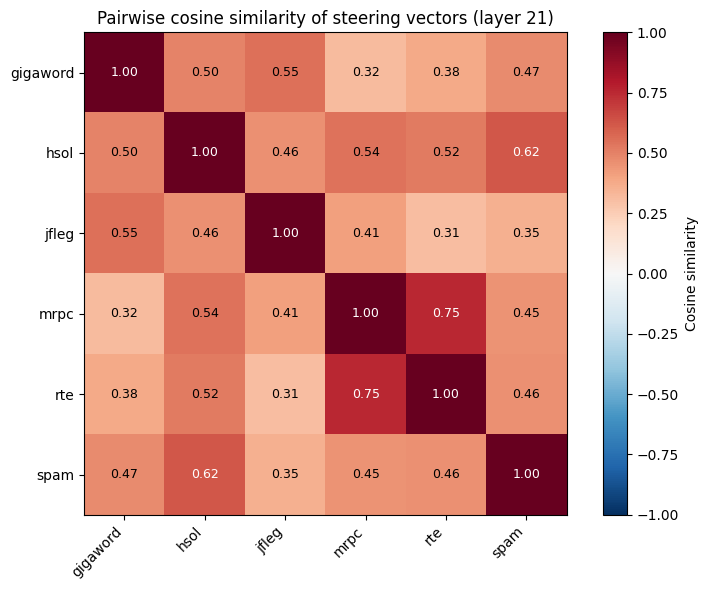


Off-diagonal cosine: mean=0.473, std=0.114, min=0.310, max=0.753


In [ ]:
# ================================================================
# PAIRWISE COSINE MATRIX ACROSS OPI COVER TASKS
# ================================================================

LAYER = 21

hook_name = f"blocks.{LAYER}.hook_resid_post"

prompts_by_task = {
    task: opi.data_all_attack_types(opi_ds, model, task_type="sentiment", injected_task=task) for task in ["spam", "hsol", "rte", "mrpc", "jfleg", 'gigaword']
}

def get_mean_resid(prompt_list):
    """Mean residual stream at last token, layer LAYER."""
    resids = []
    for p in prompt_list:
        _, cache = model.run_with_cache(
            p,
            names_filter=lambda n: n == hook_name,
            remove_batch_dim=True
        )
        resids.append(cache[hook_name][-1].detach().cpu().float())
    return torch.stack(resids).mean(dim=0)  # [d_model]

# --- Compute one steering vector per task ---
task_names = sorted(prompts_by_task.keys())
vectors = {}
for task in task_names:
    mean_combine = get_mean_resid(prompts_by_task[task]["combine"])
    mean_naive   = get_mean_resid(prompts_by_task[task]["naive"])
    vectors[task] = mean_combine - mean_naive
    print(f"{task}: vec norm = {vectors[task].norm():.3f}")

# --- Pairwise cosine similarity matrix ---
n = len(task_names)
cos_matrix = np.zeros((n, n))
for i, t1 in enumerate(task_names):
    for j, t2 in enumerate(task_names):
        cos_matrix[i, j] = torch.nn.functional.cosine_similarity(
            vectors[t1].unsqueeze(0), vectors[t2].unsqueeze(0)
        ).item()

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cos_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(task_names, rotation=45, ha="right")
ax.set_yticklabels(task_names)

# Annotate cells
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{cos_matrix[i,j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(cos_matrix[i,j]) > 0.6 else "black")

ax.set_title(f"Pairwise cosine similarity of steering vectors (layer {LAYER})")
plt.colorbar(im, ax=ax, label="Cosine similarity")
plt.tight_layout()
plt.show()

# --- Summary stats ---
off_diag = cos_matrix[np.triu_indices(n, k=1)]
print(f"\nOff-diagonal cosine: mean={off_diag.mean():.3f}, "
      f"std={off_diag.std():.3f}, min={off_diag.min():.3f}, max={off_diag.max():.3f}")

We observe an overall strong cosine similarity (off-diagonal mean=0.47).
The similarity is even stronger when we group tasks by output form similarity: some injections require a fixed-form output (predefined answers), while others require a free-form one (summary for example)

If we group similar injected tasks together, the pattern appears more clearly:

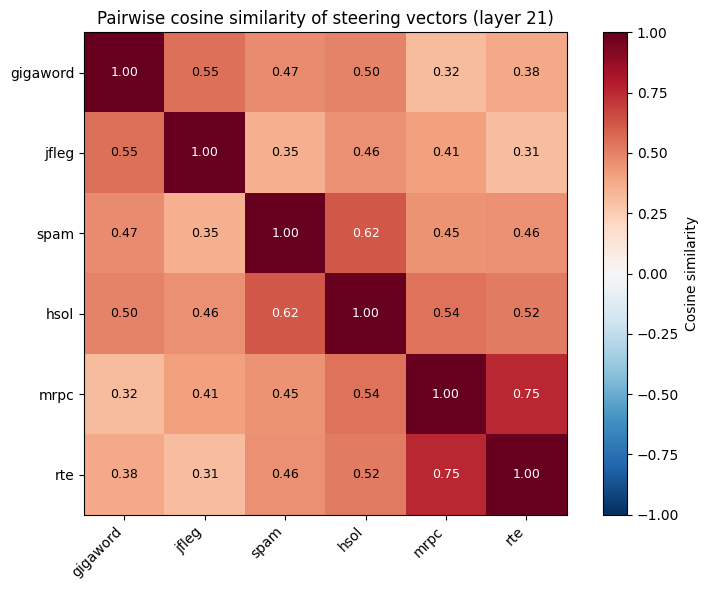

In [ ]:
# ================================================================
# PAIRWISE COSINE MATRIX ACROSS OPI COVER TASKS, GROUPED BY TYPE
# ================================================================

# --- Compute one steering vector per task ---
task_names = ["gigaword", "jfleg", "spam", "hsol", "mrpc", "rte"]
vectors = {}
for task in task_names:
    mean_combine = get_mean_resid(prompts_by_task[task]["combine"])
    mean_naive   = get_mean_resid(prompts_by_task[task]["naive"])
    vectors[task] = mean_combine - mean_naive
    print(f"{task}: vec norm = {vectors[task].norm():.3f}")

# --- Pairwise cosine similarity matrix ---

n = len(task_names)
cos_matrix = np.zeros((n, n))
for i, t1 in enumerate(task_names):
    for j, t2 in enumerate(task_names):
        cos_matrix[i, j] = torch.nn.functional.cosine_similarity(
            vectors[t1].unsqueeze(0), vectors[t2].unsqueeze(0)
        ).item()

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cos_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(task_names, rotation=45, ha="right")
ax.set_yticklabels(task_names)

# Annotate cells
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{cos_matrix[i,j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(cos_matrix[i,j]) > 0.6 else "black")

ax.set_title(f"Pairwise cosine similarity of steering vectors (layer {LAYER})")
plt.colorbar(im, ax=ax, label="Cosine similarity")
plt.tight_layout()
plt.show()


# --- Summary stats ---
off_diag = cos_matrix[np.triu_indices(n, k=1)]
print(f"\nOff-diagonal cosine: mean={off_diag.mean():.3f}, "
      f"std={off_diag.std():.3f}, min={off_diag.min():.3f}, max={off_diag.max():.3f}")

# Visualization of task-specific steering vectors by PCA

Variance explained per PC:
  PC1: 0.372  (cumulative: 0.372)
  PC2: 0.254  (cumulative: 0.626)
  PC3: 0.184  (cumulative: 0.810)
  PC4: 0.135  (cumulative: 0.946)
  PC5: 0.054  (cumulative: 1.000)


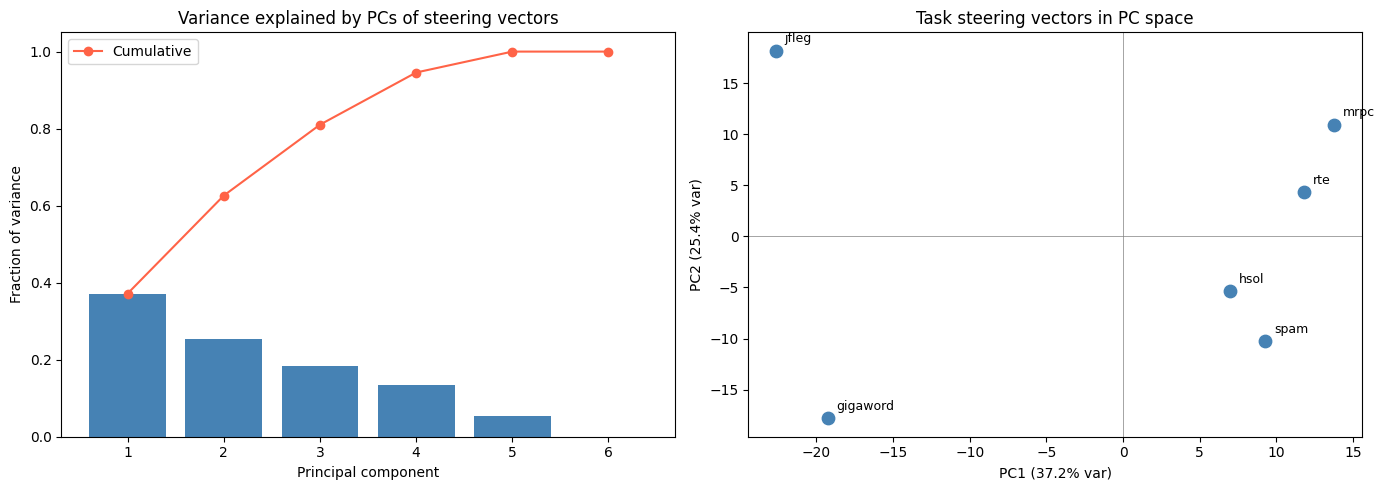


PC1 norm: 1.0000 (should be ~1)

Cosine similarity of each task vector with PC1:
  gigaword            : -0.628
  hsol                : -0.018
  jfleg               : -0.700
  mrpc                : 0.192
  rte                 : 0.190
  spam                : 0.047


In [ ]:
# ================================================================
# PCA OF STEERING VECTORS ACROSS TASKS
# ================================================================

# Stack all steering vectors into a matrix [n_tasks, d_model]
task_names_sorted = sorted(vectors.keys())
V = torch.stack([vectors[t] for t in task_names_sorted]).numpy()  # [n_tasks, d_model]

# Center
V_centered = V - V.mean(axis=0, keepdims=True)

# SVD
U, S, Vt = np.linalg.svd(V_centered, full_matrices=False)

# Variance explained
var_explained = S**2 / (S**2).sum()
cumulative = np.cumsum(var_explained)

print("Variance explained per PC:")
for i, (ve, cum) in enumerate(zip(var_explained, cumulative)):
    print(f"  PC{i+1}: {ve:.3f}  (cumulative: {cum:.3f})")
    if cum > 0.95:
        break

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
n_show = min(len(S), 10)
axes[0].bar(range(1, n_show+1), var_explained[:n_show], color="steelblue")
axes[0].plot(range(1, n_show+1), cumulative[:n_show], 'o-', color="tomato", label="Cumulative")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Fraction of variance")
axes[0].set_title("Variance explained by PCs of steering vectors")
axes[0].legend()
axes[0].set_xticks(range(1, n_show+1))

# Project each task vector onto PC1 vs PC2
projections = U[:, :2] * S[:2]  # [n_tasks, 2]
axes[1].scatter(projections[:, 0], projections[:, 1], s=80, color="steelblue")
for i, name in enumerate(task_names_sorted):
    axes[1].annotate(name, (projections[i, 0], projections[i, 1]),
                     textcoords="offset points", xytext=(6, 6), fontsize=9)
axes[1].set_xlabel(f"PC1 ({var_explained[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({var_explained[1]:.1%} var)")
axes[1].set_title("Task steering vectors in PC space")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

# --- The shared injection direction (PC1) ---
shared_direction = torch.tensor(Vt[0], dtype=torch.float32)  # [d_model]
print(f"\nPC1 norm: {np.linalg.norm(Vt[0]):.4f} (should be ~1)")

# Cosine of each task vector with PC1
print("\nCosine similarity of each task vector with PC1:")
for t in task_names_sorted:
    cos = torch.nn.functional.cosine_similarity(
        vectors[t].unsqueeze(0),
        shared_direction.unsqueeze(0)
    ).item()
    print(f"  {t:20s}: {cos:.3f}")

Two clusters are clearly defined, corresponding to free-form tasks vs. fixed-form tasks.
There isn't one or two principal components explaining most of the variance.

Let's perform PCA again between fixed-form tasks:

In [ ]:
# ================================================================
# WITHIN-CLUSTER PCA: fixed-form tasks only
# ================================================================

classif_tasks = ["spam", "hsol", "mrpc", "rte"]
V_classif = torch.stack([vectors[t] for t in classif_tasks]).numpy()
V_classif_c = V_classif - V_classif.mean(axis=0, keepdims=True)

_, S_c, Vt_c = np.linalg.svd(V_classif_c, full_matrices=False)
var_c = S_c**2 / (S_c**2).sum()

print("Classification tasks only:")
for i, v in enumerate(var_c):
    print(f"  PC{i+1}: {v:.3f}  (cum: {var_c[:i+1].sum():.3f})")

# Cosine of each classif vector with within-cluster PC1
shared_classif = torch.tensor(Vt_c[0], dtype=torch.float32)
print("\nCosine with classification-PC1:")
for t in classif_tasks:
    cos = torch.nn.functional.cosine_similarity(
        vectors[t].unsqueeze(0), shared_classif.unsqueeze(0)
    ).item()
    print(f"  {t:15s}: {cos:.3f}")

# Same for free-form
freeform_tasks = ["jfleg", "gigaword"]  # adjust
V_free = torch.stack([vectors[t] for t in freeform_tasks]).numpy()
# With n=2, PC1 is trivially the mean direction
shared_free = torch.tensor(V_free.mean(axis=0), dtype=torch.float32)
shared_free = shared_free / shared_free.norm()
cos_free = torch.nn.functional.cosine_similarity(
    vectors[freeform_tasks[0]].unsqueeze(0),
    vectors[freeform_tasks[1]].unsqueeze(0)
).item()
print(f"\nFree-form inter-task cosine: {cos_free:.3f}")

Classification tasks only:
  PC1: 0.509  (cum: 0.509)
  PC2: 0.349  (cum: 0.858)
  PC3: 0.142  (cum: 1.000)
  PC4: 0.000  (cum: 1.000)

Cosine with classification-PC1:
  spam           : -0.594
  hsol           : -0.578
  mrpc           : 0.242
  rte            : 0.184

Free-form inter-task cosine: 0.552


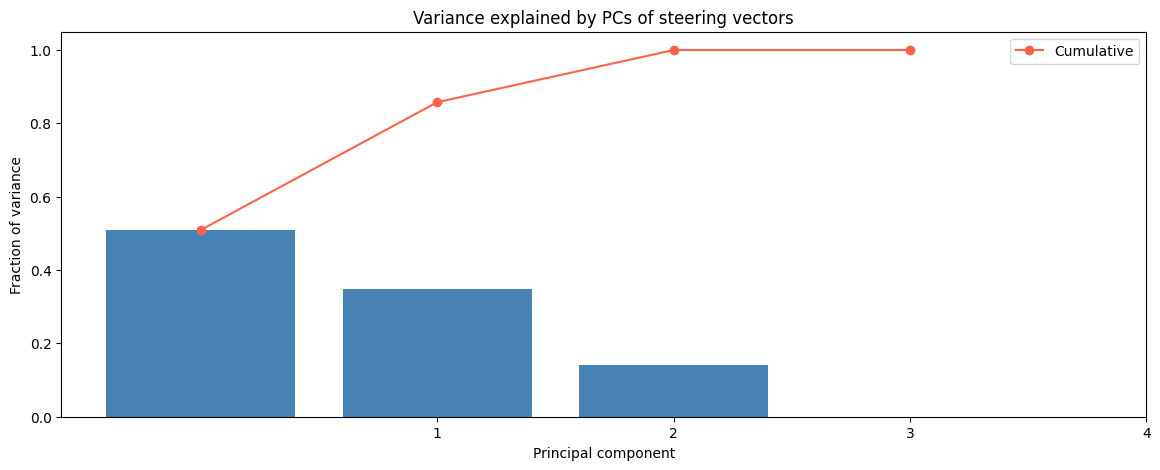

In [ ]:
# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Scree plot
n_show = len(var_c)
ax.bar(range(n_show),var_c, color="steelblue")
ax.plot(var_c.cumsum(), 'o-', color="tomato", label="Cumulative")
ax.set_xlabel("Principal component")
ax.set_ylabel("Fraction of variance")
ax.set_title("Variance explained by PCs of steering vectors")
ax.legend()
ax.set_xticks(range(1, n_show+1))

Even the fixed-form cluster is divided into two sub-clusters, grouping together similar tasks.
The nature of the task therefore has still a strong influence overall on the diff-of-means vector in the residual stream. 

# Removing the steering vector

Now, we will instead remove, for each task, on combine attacks, the direction of the steering vector from the residual stream and see if this correlates with a decrease of attack success rate. If it happens, the direction found is not only sufficient but necessary for injection success.

In [ ]:
# ================================================================
# NECESSITY ABLATION — PER TASK
# ================================================================

LAYER = 21
hook_name = f"blocks.{LAYER}.hook_resid_post"

results = {}

def asr_from_logits(logits_list, inject_ids, original_ids):
    """Fraction of samples where P(inject) > P(original)."""
    successes = 0
    for logits in logits_list:
        p_inject = logits[inject_ids].logsumexp(0)
        p_original = logits[original_ids].logsumexp(0)
        if p_inject > p_original:
            successes += 1
    return successes / len(logits_list)

for task in ["spam", "hsol", "mrpc", "rte"]:
    # Task-specific steering direction (unit norm)
    steer_dir = vectors[task] / vectors[task].norm()
    steer_dir = steer_dir.to(model.cfg.device)

    def make_ablation_hook(direction):
        def hook_fn(resid, hook):
            proj = torch.einsum("d, ...d -> ...", direction, resid[:, -1, :])
            resid[:, -1, :] -= proj.unsqueeze(-1) * direction.unsqueeze(0)
            return resid
        return hook_fn

    baseline_logits = []
    ablated_logits = []

    for p in prompts_by_task[task]["combine"]:
        # Baseline
        logits = model(p)
        baseline_logits.append(logits[0, -1, :].detach().cpu())
        # Ablated
        logits_abl = model.run_with_hooks(
            p,
            fwd_hooks=[(hook_name, make_ablation_hook(steer_dir))]
        )
        ablated_logits.append(logits_abl[0, -1, :].detach().cpu())

    # >>> ADAPT THESE per task — you need task-specific token ID lists <
    inject_ids  = to_first_token_ids(ANSWER_STRINGS[task])
    original_ids = to_first_token_ids(ANSWER_STRINGS["sentiment"])

    asr_base = asr_from_logits(baseline_logits, inject_ids, original_ids)
    asr_abl  = asr_from_logits(ablated_logits, inject_ids, original_ids)

    results[task] = {"baseline": asr_base, "ablated": asr_abl, "drop": asr_base - asr_abl}
    print(f"{task:15s}  baseline={asr_base:.1%}  ablated={asr_abl:.1%}  drop={asr_base - asr_abl:.1%}")

# --- Summary ---
drops = [r["drop"] for r in results.values()]
print(f"\nMean ASR drop: {np.mean(drops):.1%} ± {np.std(drops):.1%}")

spam             baseline=100.0%  ablated=100.0%  drop=0.0%
hsol             baseline=100.0%  ablated=99.0%  drop=1.0%
mrpc             baseline=100.0%  ablated=100.0%  drop=0.0%
rte              baseline=100.0%  ablated=100.0%  drop=0.0%

Mean ASR drop: 0.3% ± 0.4%


No drop. To adjust for Hydra effect, we will ablate this direction from layer 21 onward.

In [ ]:
# ================================================================
# NECESSITY ABLATION — PERSISTENT PROJECTION
# ================================================================

LAYER_START = 21  # project out from this layer onward

results = {}

for task in sorted(prompts_by_task.keys()):
    if task in freeform_tasks:
        continue

    steer_dir = vectors[task] / vectors[task].norm()
    steer_dir = steer_dir.to(model.cfg.device)

    def make_ablation_hook(direction):
        def hook_fn(resid, hook):
            proj = torch.einsum("d, ...d -> ...", direction, resid[:, -1, :])
            resid[:, -1, :] -= proj.unsqueeze(-1) * direction.unsqueeze(0)
            return resid
        return hook_fn

    # Hook at every layer from LAYER_START onward
    hook_list = [
        (f"blocks.{l}.hook_resid_post", make_ablation_hook(steer_dir))
        for l in range(LAYER_START, model.cfg.n_layers)
    ]

    baseline_logits = []
    ablated_logits = []

    for p in prompts_by_task[task]["combine"]:
        logits = model(p)
        baseline_logits.append(logits[0, -1, :].detach().cpu())

        logits_abl = model.run_with_hooks(p, fwd_hooks=hook_list)
        ablated_logits.append(logits_abl[0, -1, :].detach().cpu())

    inject_ids  = to_first_token_ids(ANSWER_STRINGS[task])
    original_ids = to_first_token_ids(ANSWER_STRINGS["sentiment"])

    asr_base = asr_from_logits(baseline_logits, inject_ids, original_ids)
    asr_abl  = asr_from_logits(ablated_logits, inject_ids, original_ids)

    results[task] = {"baseline": asr_base, "ablated": asr_abl, "drop": asr_base - asr_abl}
    print(f"{task:15s}  baseline={asr_base:.1%}  ablated={asr_abl:.1%}  drop={asr_base - asr_abl:.1%}")

drops = [r["drop"] for r in results.values()]
print(f"\nMean ASR drop: {np.mean(drops):.1%} ± {np.std(drops):.1%}")

hsol             baseline=100.0%  ablated=100.0%  drop=0.0%
mrpc             baseline=100.0%  ablated=100.0%  drop=0.0%
rte              baseline=100.0%  ablated=100.0%  drop=0.0%


KeyboardInterrupt: 

No drop again. Perhaps the mean projected value of the residual stream in that direction is actually negative when there is no injection; therefore ablating this component doesn't actually remove the injection effect.

In [ ]:
# ================================================================
# DIAGNOSTIC: projection magnitudes by condition
# ================================================================

for task in ["spam", "hsol", "mrpc", "rte"]:
    steer_dir = vectors[task] / vectors[task].norm()
    steer_dir = steer_dir.to(model.cfg.device)

    hook_name = f"blocks.{LAYER}.hook_resid_post"

    for cond in ["naive", "combine"]:
        projs = []
        for p in prompts_by_task[task][cond]:
            _, cache = model.run_with_cache(
                p,
                names_filter=lambda n: n == hook_name,
                remove_batch_dim=True
            )
            proj = torch.dot(cache[hook_name][-1].float().cpu(), steer_dir.cpu()).item()
            projs.append(proj)
        print(f"{task:12s} {cond:8s}  proj: mean={np.mean(projs):+.2f}  std={np.std(projs):.2f}")
    print()

spam         naive     proj: mean=-15.04  std=3.33
spam         combine   proj: mean=+19.12  std=2.01

hsol         naive     proj: mean=-24.23  std=3.14
hsol         combine   proj: mean=+14.24  std=2.58

mrpc         naive     proj: mean=-19.23  std=2.37
mrpc         combine   proj: mean=+12.38  std=3.26

rte          naive     proj: mean=-21.85  std=3.24
rte          combine   proj: mean=-0.06  std=3.54



Hypothesis confirmed: residual streams for naive prompts show a significant negative value along that direction. We should adjust all the way

In [ ]:
# ================================================================
# NECESSITY ABLATION — CLAMP TO NAIVE PROJECTION
# ================================================================

LAYER_START = 18  # start a few layers before peak

results = {}

for task in ["spam", "hsol", "mrpc", "rte"]:
    steer_dir = vectors[task] / vectors[task].norm()
    steer_dir = steer_dir.to(model.cfg.device)

    # Get naive mean projection at each layer
    naive_projs_by_layer = {}
    for l in range(LAYER_START, model.cfg.n_layers):
        hn = f"blocks.{l}.hook_resid_post"
        projs = []
        for p in prompts_by_task[task]["naive"]:
            _, cache = model.run_with_cache(
                p, names_filter=lambda n, hn=hn: n == hn,
                remove_batch_dim=True
            )
            projs.append(torch.dot(cache[hn][-1].float().cpu(), steer_dir.cpu()).item())
        naive_projs_by_layer[l] = np.mean(projs)

    def make_clamp_hook(direction, target_proj):
        def hook_fn(resid, hook):
            current_proj = torch.einsum("d, ...d -> ...", direction, resid[:, -1, :])
            shift = target_proj - current_proj
            resid[:, -1, :] += shift.unsqueeze(-1) * direction.unsqueeze(0)
            return resid
        return hook_fn

    hook_list = [
        (f"blocks.{l}.hook_resid_post",
         make_clamp_hook(steer_dir, naive_projs_by_layer[l]))
        for l in range(LAYER_START, model.cfg.n_layers)
    ]

    baseline_logits = []
    clamped_logits = []

    for p in prompts_by_task[task]["combine"]:
        logits = model(p)
        baseline_logits.append(logits[0, -1, :].detach().cpu())

        logits_cl = model.run_with_hooks(p, fwd_hooks=hook_list)
        clamped_logits.append(logits_cl[0, -1, :].detach().cpu())

    inject_ids  = to_first_token_ids(ANSWER_STRINGS[task])
    original_ids = to_first_token_ids(ANSWER_STRINGS["sentiment"])

    asr_base = asr_from_logits(baseline_logits, inject_ids, original_ids)
    asr_cl   = asr_from_logits(clamped_logits, inject_ids, original_ids)

    results[task] = {"baseline": asr_base, "clamped": asr_cl, "drop": asr_base - asr_cl}
    print(f"{task:15s}  baseline={asr_base:.1%}  clamped={asr_cl:.1%}  drop={asr_base - asr_cl:.1%}")

spam             baseline=100.0%  clamped=0.0%  drop=100.0%
hsol             baseline=100.0%  clamped=0.0%  drop=100.0%
mrpc             baseline=100.0%  clamped=6.0%  drop=94.0%
rte              baseline=100.0%  clamped=95.5%  drop=4.5%


Here the drop is successful! The direction seems indeed necessary.
Let's keep an eye on "rte" task however, whose much smaller drop should invite us to caution.